<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MineriaDatos_S6_Clustering_Laboratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗂️ Minería de Datos — Semana 6: Clustering
## K-Means · DBSCAN · SOM · Métricas de Evaluación

**Tecnicatura Superior en Ciencias de Datos e Inteligencia Artificial**  
**Politécnico Malvinas Argentinas**

---
### 🎯 Objetivos de la clase
- Comprender la diferencia entre aprendizaje supervisado y **no supervisado**
- Implementar y comparar **K-Means**, **DBSCAN** y **SOM**
- Elegir el número de clusters con **Elbow** y **Silhouette**
- Evaluar resultados con métricas: **Silhouette Score**, **Davies-Bouldin**, **Calinski-Harabász**
- Aplicar clustering a un caso real de **segmentación RFM**

---
### 📋 Contenido
| Sección | Tema |
|---------|------|
| S0 | Setup y datos |
| S1 | Distancias y similitud |
| S2 | K-Means: algoritmo, elbow, silhouette |
| S3 | DBSCAN: densidad y ruido |
| S4 | SOM: mapas auto-organizados |
| S5 | Métricas de evaluación |
| S6 | Caso real: segmentación RFM |
| S7 | Comparativa y cierre |


---
## ⚙️ S0 · Setup

### Instalación de dependencias
Ejecutá esta celda solo si es la primera vez o si falta algún paquete:

In [ ]:
# Instalación (descomentar si es necesario)
# !pip install scikit-learn minisom matplotlib seaborn pandas numpy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


### Datasets que usaremos
Generamos varios conjuntos de datos para explorar distintos escenarios de clustering:

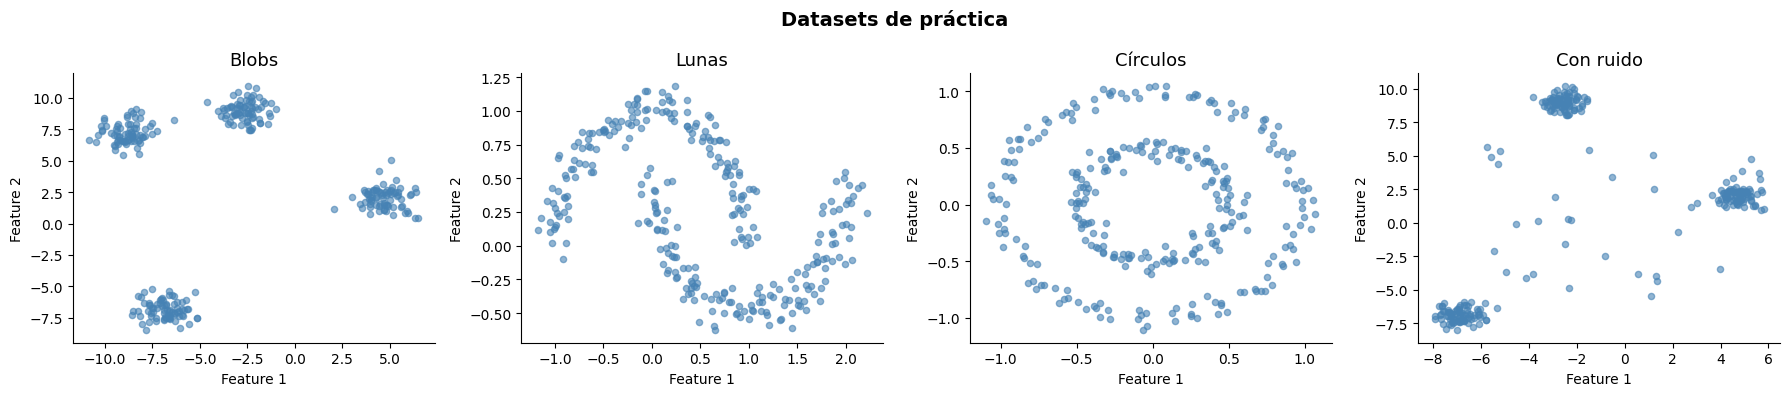

Blobs: (300, 2) | Moons: (300, 2) | Circles: (300, 2) | Noisy: (280, 2)


In [ ]:
# Dataset 1: Blobs bien separados (ideal para K-Means)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4,
                               cluster_std=0.8, random_state=42)

# Dataset 2: Lunas (no linealmente separables)
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# Dataset 3: Círculos concéntricos
X_circles, _ = make_circles(n_samples=300, noise=0.05,
                              factor=0.5, random_state=42)

# Dataset 4: Con ruido y outliers (ideal para DBSCAN)
X_noisy, y_noisy = make_blobs(n_samples=250, centers=3,
                               cluster_std=0.5, random_state=42)
noise = np.random.uniform(-6, 6, size=(30, 2))
X_noisy = np.vstack([X_noisy, noise])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
datasets = [(X_blobs, 'Blobs'), (X_moons, 'Lunas'),
            (X_circles, 'Círculos'), (X_noisy, 'Con ruido')]
for ax, (X, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], alpha=0.6, s=20, c='steelblue')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
plt.suptitle('Datasets de práctica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Blobs: {X_blobs.shape} | Moons: {X_moons.shape} | Circles: {X_circles.shape} | Noisy: {X_noisy.shape}')

---
## 📐 S1 · Distancias y Similitud

Las métricas de distancia son la base de todos los algoritmos de clustering.  
Elegir la correcta impacta directamente en la calidad de los resultados.

| Métrica | Fórmula | Cuándo usarla |
|---------|---------|---------------|
| **Euclidiana** | √Σ(xᵢ−yᵢ)² | Datos numéricos, misma escala |
| **Manhattan** | Σ|xᵢ−yᵢ| | Datos con outliers, grillas |
| **Coseno** | 1 − (x·y)/(‖x‖‖y‖) | Datos textuales, embeddings |

=== Distancias entre p1 y p2 ===
  Euclidiana : 5.0000
  Manhattan  : 7.0000
  Coseno     : 0.0077

=== Distancias entre p1 y p3 ===
  Euclidiana : 9.1984  ← muy diferente
  Manhattan  : 10.9000  ← muy diferente
  Coseno     : 0.5439  ← similar dirección!


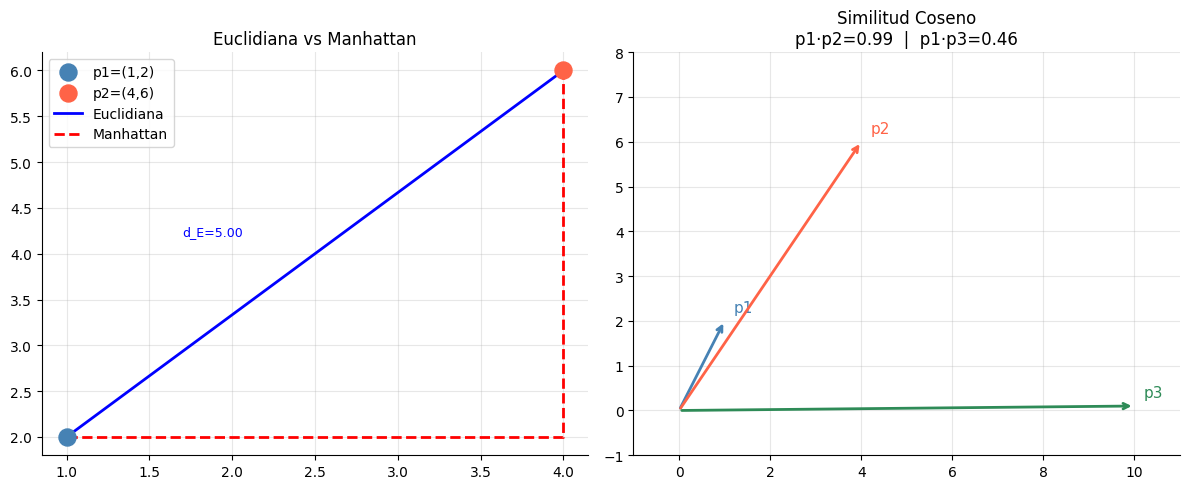

In [ ]:
from scipy.spatial.distance import euclidean, cityblock, cosine

# Tres puntos de ejemplo
p1 = np.array([1, 2])
p2 = np.array([4, 6])
p3 = np.array([10, 0.1])  # en dirección similar a p1 pero lejos

print('=== Distancias entre p1 y p2 ===')
print(f'  Euclidiana : {euclidean(p1, p2):.4f}')
print(f'  Manhattan  : {cityblock(p1, p2):.4f}')
print(f'  Coseno     : {cosine(p1, p2):.4f}')

print('\n=== Distancias entre p1 y p3 ===')
print(f'  Euclidiana : {euclidean(p1, p3):.4f}  ← muy diferente')
print(f'  Manhattan  : {cityblock(p1, p3):.4f}  ← muy diferente')
print(f'  Coseno     : {cosine(p1, p3):.4f}  ← similar dirección!')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Euclidiana vs Manhattan
ax = axes[0]
ax.scatter(*p1, color='steelblue', s=150, zorder=5, label='p1=(1,2)')
ax.scatter(*p2, color='tomato', s=150, zorder=5, label='p2=(4,6)')
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', lw=2, label='Euclidiana')
ax.plot([p1[0], p2[0], p2[0]], [p1[1], p1[1], p2[1]], 'r--', lw=2, label='Manhattan')
ax.legend(); ax.set_title('Euclidiana vs Manhattan'); ax.grid(alpha=0.3)
ax.text((p1[0]+p2[0])/2-0.8, (p1[1]+p2[1])/2+0.2,
        f'd_E={euclidean(p1,p2):.2f}', color='blue', fontsize=9)

# Similitud coseno
ax2 = axes[1]
origin = [0, 0]
vecs = {'p1': (p1, 'steelblue'), 'p2': (p2, 'tomato'), 'p3': (p3, 'seagreen')}
for name, (v, c) in vecs.items():
    ax2.annotate('', xy=v, xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax2.text(v[0]+0.2, v[1]+0.2, name, color=c, fontsize=11)
ax2.set_xlim(-1, 11); ax2.set_ylim(-1, 8)
ax2.set_title(f'Similitud Coseno\np1·p2={1-cosine(p1,p2):.2f}  |  p1·p3={1-cosine(p1,p3):.2f}')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 🔬 Ejercicio S1
> **Calculá las distancias entre los siguientes vectores y analizá cuál métrica es más apropiada:**
> - `a = [3, 0, 4, 0, 2]`
> - `b = [1, 1, 1, 1, 1]`
> - `c = [6, 0, 8, 0, 4]`  ← ¿notás algo con la distancia coseno respecto a `a`?
>
> Pensá: si estos vectores representaran **frecuencias de palabras** en documentos,  
> ¿qué métrica usarías para agruparlos?

In [ ]:
# Tu código aquí
a = np.array([3, 0, 4, 0, 2])
b = np.array([1, 1, 1, 1, 1])
c = np.array([6, 0, 8, 0, 4])

# Calculá las tres métricas entre cada par
# Tip: usá euclidean(), cityblock(), cosine() de scipy.spatial.distance


---
## 🎯 S2 · K-Means: Algoritmo, Elbow y Silhouette

**K-Means** divide los datos en *k* grupos minimizando la **inercia** (suma de distancias al centroide).

### Algoritmo (4 pasos):
1. **Inicializar** *k* centroides (random o KMeans++)
2. **Asignar** cada punto al centroide más cercano
3. **Actualizar** cada centroide como la media de su cluster
4. **Repetir** 2-3 hasta convergencia


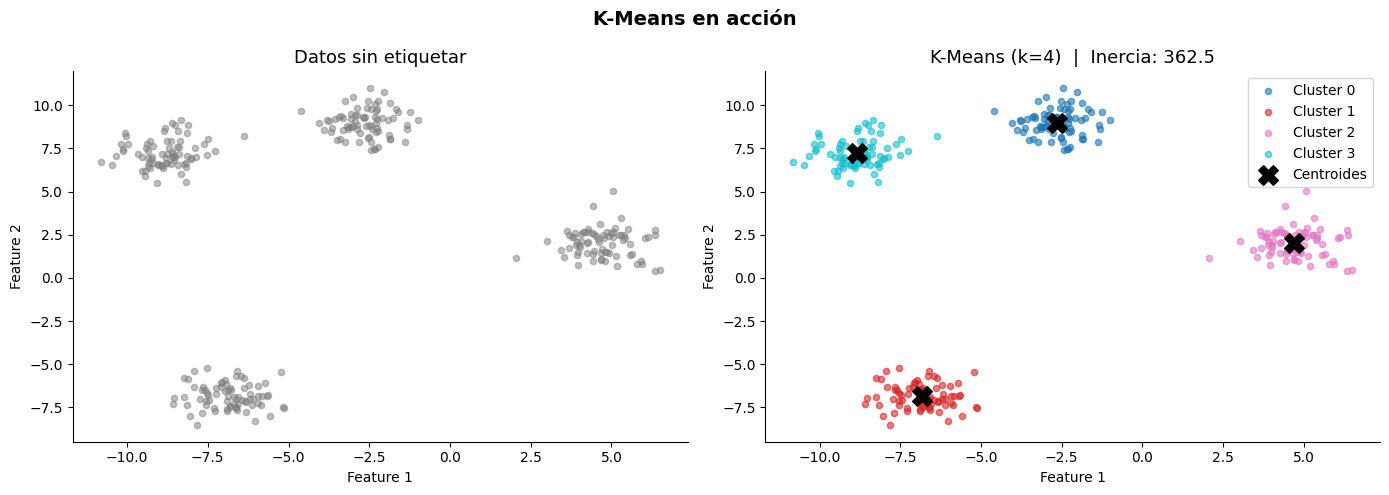

Inercia: 362.47
Iteraciones hasta convergencia: 3


In [ ]:
# Demo: paso a paso de K-Means
from sklearn.cluster import KMeans

# Entrenamos con k=4 (sabemos que hay 4 blobs)
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos originales (sin etiquetas)
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], alpha=0.5, s=20, c='gray')
axes[0].set_title('Datos sin etiquetar', fontsize=13)
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# Resultado K-Means
colors = plt.cm.tab10(np.linspace(0, 1, 4))
for k in range(4):
    mask = labels_km == k
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                   c=[colors[k]], alpha=0.6, s=20, label=f'Cluster {k}')
axes[1].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centroides')
axes[1].set_title(f'K-Means (k=4)  |  Inercia: {kmeans.inertia_:.1f}', fontsize=13)
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.suptitle('K-Means en acción', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Inercia: {kmeans.inertia_:.2f}')
print(f'Iteraciones hasta convergencia: {kmeans.n_iter_}')

### 📉 Método del Codo (Elbow)
Para elegir *k*, graficamos la inercia vs k y buscamos el **codo**: punto donde agregar más clusters
ya no reduce significativamente la inercia.

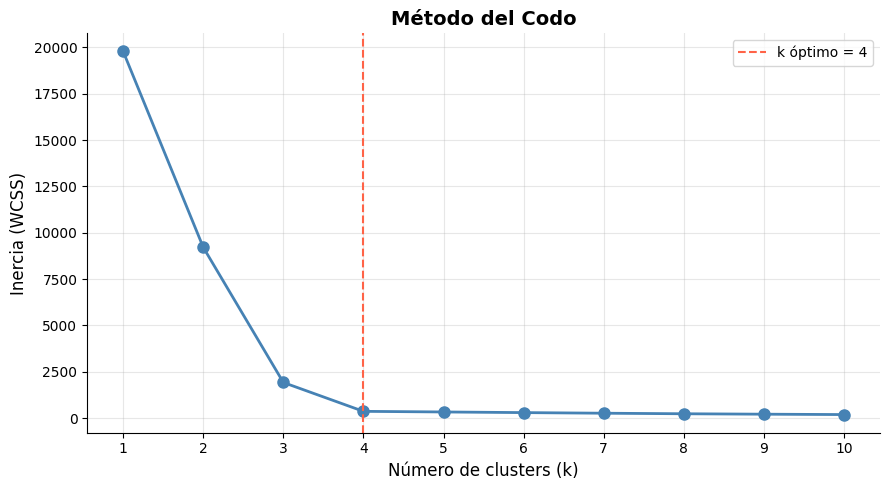

k  | Inercia     | Reducción %
-----------------------------------
 1 |    19780.3 | -
 2 |     9211.2 |  53.4%
 3 |     1919.4 |  79.2%
 4 |      362.5 |  81.1%
 5 |      329.3 |   9.2%
 6 |      294.6 |  10.5%
 7 |      261.6 |  11.2%
 8 |      232.0 |  11.3%
 9 |      209.1 |   9.9%
10 |      188.7 |   9.7%


In [ ]:
# Método del Codo
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'o-', color='steelblue', lw=2, ms=8)
plt.axvline(x=4, color='tomato', linestyle='--', lw=1.5, label='k óptimo = 4')
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('Método del Codo', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.tight_layout(); plt.show()

# Mostrar la reducción relativa
print('k  | Inercia     | Reducción %')
print('-' * 35)
for i, (k, iner) in enumerate(zip(k_range, inertias)):
    if i == 0:
        print(f'{k:2d} | {iner:10.1f} | -')
    else:
        pct = (inertias[i-1] - iner) / inertias[i-1] * 100
        print(f'{k:2d} | {iner:10.1f} | {pct:5.1f}%')

### 📊 Silhouette Score
Mide qué tan similar es un punto a su propio cluster comparado con otros clusters.  
**Rango: [-1, 1]** — valores cercanos a 1 indican clusters bien definidos.

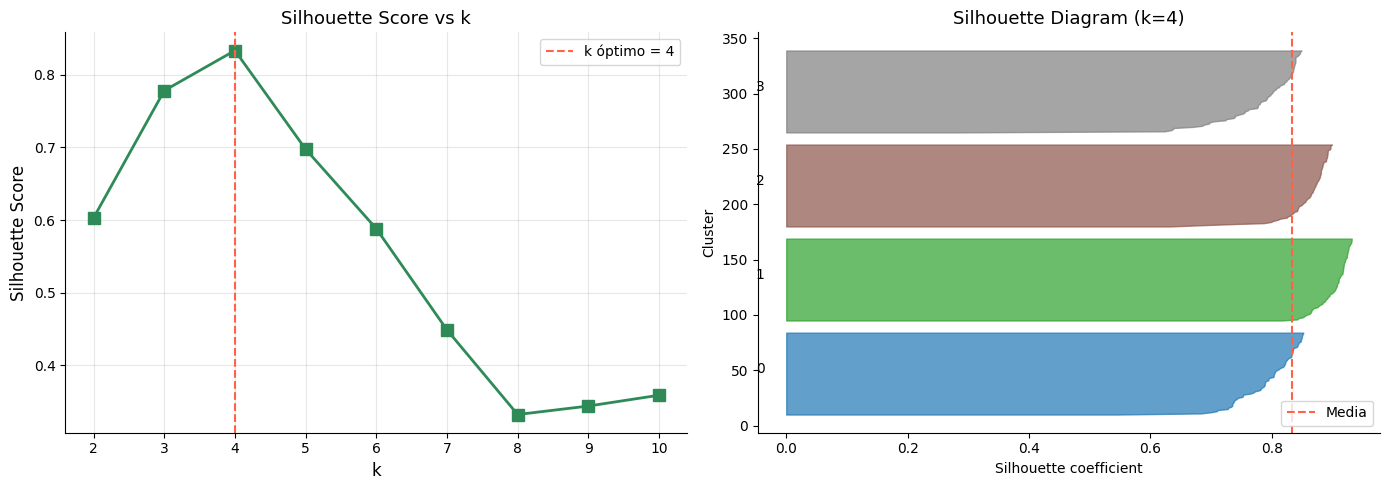

Mejor k: 4  |  Silhouette score: 0.8335


In [ ]:
# Silhouette Score para distintos valores de k
sil_scores = []
k_range2 = range(2, 11)  # silhouette requiere k >= 2

for k in k_range2:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_blobs)
    score = silhouette_score(X_blobs, labels)
    sil_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de línea
axes[0].plot(k_range2, sil_scores, 's-', color='seagreen', lw=2, ms=8)
best_k = k_range2[np.argmax(sil_scores)]
axes[0].axvline(x=best_k, color='tomato', linestyle='--',
               label=f'k óptimo = {best_k}')
axes[0].set_xlabel('k', fontsize=12); axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score vs k', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(list(k_range2))

# Silhouette diagram para k óptimo
from sklearn.metrics import silhouette_samples
km_best = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
labels_best = km_best.fit_predict(X_blobs)
sil_vals = silhouette_samples(X_blobs, labels_best)

y_lower = 10
for i in range(best_k):
    ith_cluster_sil = np.sort(sil_vals[labels_best == i])
    size_k = len(ith_cluster_sil)
    y_upper = y_lower + size_k
    color = plt.cm.tab10(i / best_k)
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
    axes[1].text(-0.05, y_lower + 0.5 * size_k, str(i))
    y_lower = y_upper + 10
axes[1].axvline(x=silhouette_score(X_blobs, labels_best),
               color='tomato', linestyle='--', lw=1.5, label='Media')
axes[1].set_title(f'Silhouette Diagram (k={best_k})', fontsize=13)
axes[1].set_xlabel('Silhouette coefficient'); axes[1].set_ylabel('Cluster')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Mejor k: {best_k}  |  Silhouette score: {max(sil_scores):.4f}')

### ⚠️ Limitaciones de K-Means
K-Means **no funciona bien** en todos los escenarios. Veamos cuándo falla:

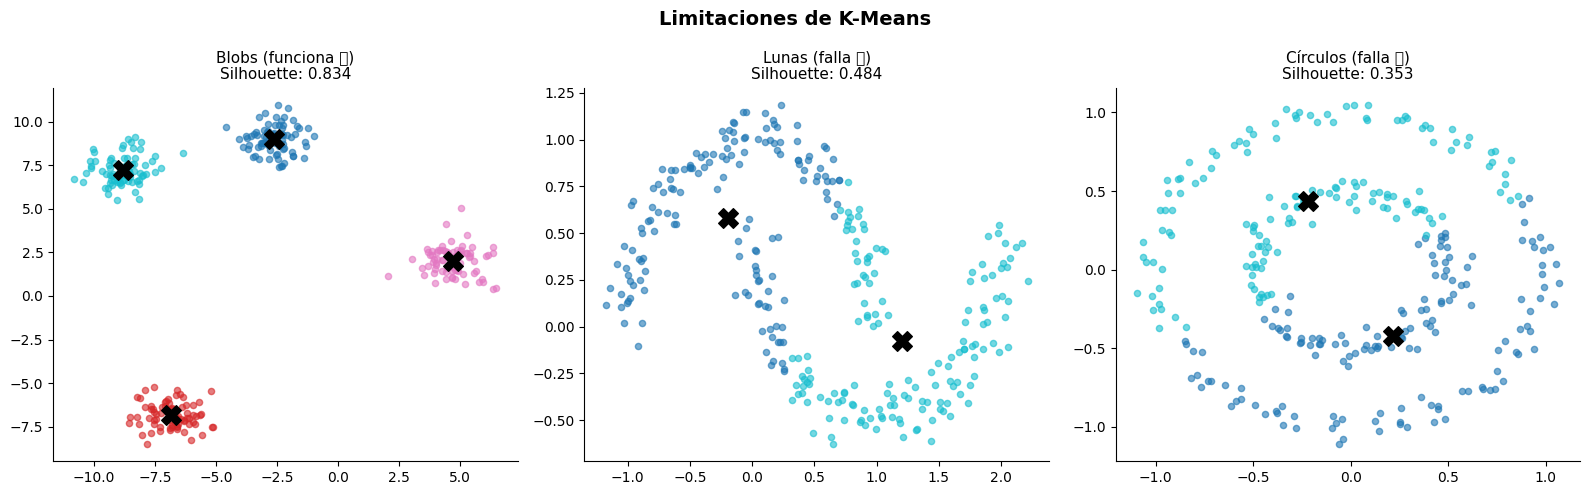

In [ ]:
# K-Means en datos no linealmente separables
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets_lim = [
    (X_blobs, 'Blobs (funciona ✅)', 4),
    (X_moons, 'Lunas (falla ❌)', 2),
    (X_circles, 'Círculos (falla ❌)', 2),
]

for ax, (X, title, k) in zip(axes, datasets_lim):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    colors = plt.cm.tab10(np.linspace(0, 1, k))
    for ki in range(k):
        mask = labels == ki
        ax.scatter(X[mask, 0], X[mask, 1], c=[colors[ki]], alpha=0.6, s=20)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
              marker='X', s=200, c='black', zorder=5)
    sil = silhouette_score(X, labels)
    ax.set_title(f'{title}\nSilhouette: {sil:.3f}', fontsize=11)
plt.suptitle('Limitaciones de K-Means', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 🔬 Ejercicio S2
> 1. Usá el dataset `X_noisy` (con outliers). Aplicá K-Means con k=3 y visualizá el resultado.
> 2. ¿El resultado parece correcto? ¿Los outliers afectan los centroides?
> 3. Calculá el Silhouette Score y compará con el resultado en `X_blobs`.
> 4. **Bonus:** Probá aplicar `StandardScaler` antes de K-Means. ¿Cambia el resultado?


In [ ]:
# Tu código aquí
# Tip: scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_noisy)


---
## 🔵 S3 · DBSCAN: Clustering Basado en Densidad

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos
en **regiones densas** y marca como **ruido** los puntos aislados.

### Parámetros clave:
- **ε (eps):** radio de vecindad — distancia máxima para ser vecino
- **MinPts:** mínimo de puntos para que una región sea densa

### Tipos de puntos:
| Tipo | Condición |
|------|-----------|
| **Core** | Tiene ≥ MinPts vecinos en radio ε |
| **Border** | Es vecino de un core, pero con < MinPts propios |
| **Noise** | No es core ni border → **outlier** |

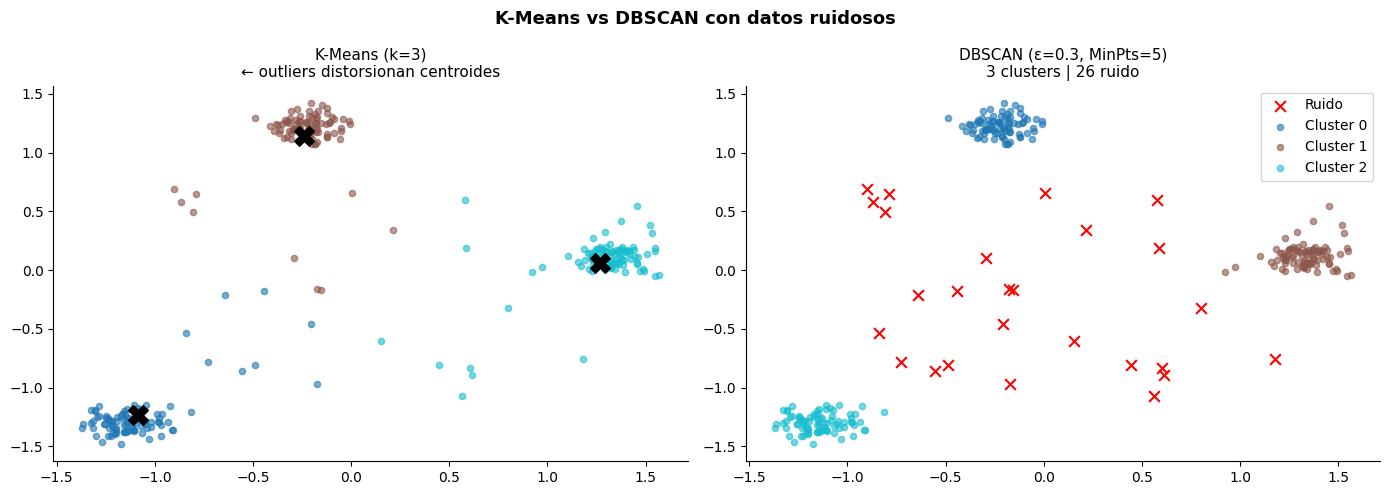

DBSCAN → Clusters: 3 | Puntos de ruido: 26/280


In [ ]:
# Demo: DBSCAN en datos con ruido
from sklearn.cluster import DBSCAN

# Normalizar primero (DBSCAN es sensible a la escala)
scaler = StandardScaler()
X_noisy_scaled = scaler.fit_transform(X_noisy)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_db = dbscan.fit_predict(X_noisy_scaled)

# -1 = ruido (noise)
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means en los mismos datos
km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_km_noisy = km.fit_predict(X_noisy_scaled)
colors_km = plt.cm.tab10(np.linspace(0, 1, 3))
for k in range(3):
    mask = labels_km_noisy == k
    axes[0].scatter(X_noisy_scaled[mask, 0], X_noisy_scaled[mask, 1],
                   c=[colors_km[k]], alpha=0.6, s=20)
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               marker='X', s=200, c='black', zorder=5)
axes[0].set_title(f'K-Means (k=3)\n← outliers distorsionan centroides', fontsize=11)

# DBSCAN
unique_labels = set(labels_db)
palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
for i, label in enumerate(sorted(unique_labels)):
    mask = labels_db == label
    if label == -1:
        axes[1].scatter(X_noisy_scaled[mask, 0], X_noisy_scaled[mask, 1],
                       c='red', marker='x', s=60, label='Ruido', zorder=5)
    else:
        axes[1].scatter(X_noisy_scaled[mask, 0], X_noisy_scaled[mask, 1],
                       c=[palette[label]], alpha=0.6, s=20, label=f'Cluster {label}')
axes[1].set_title(f'DBSCAN (ε=0.3, MinPts=5)\n{n_clusters} clusters | {n_noise} ruido', fontsize=11)
axes[1].legend()
plt.suptitle('K-Means vs DBSCAN con datos ruidosos', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'DBSCAN → Clusters: {n_clusters} | Puntos de ruido: {n_noise}/{len(X_noisy)}')

### Selección de ε con el gráfico de k-vecinos más cercanos
La heurística más usada: graficamos la distancia al **k-ésimo vecino más cercano** de cada punto
(con k = MinPts). El **codo** del gráfico sugiere un buen valor de ε.

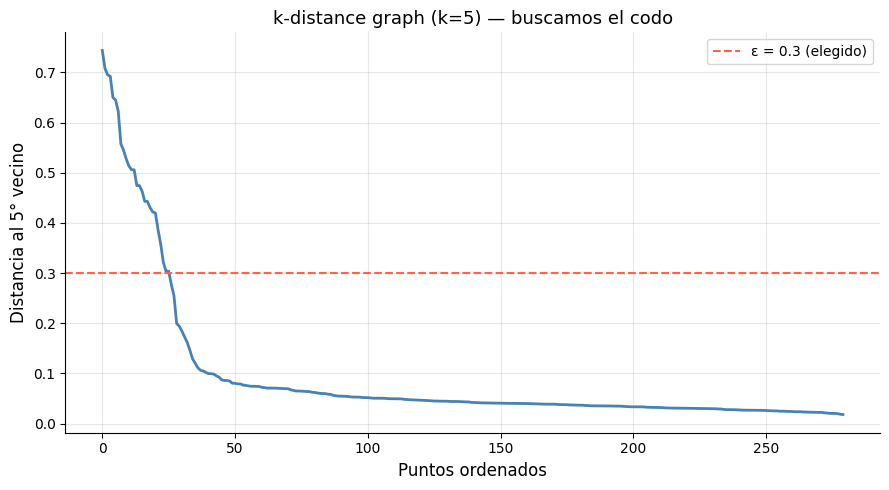

In [ ]:
from sklearn.neighbors import NearestNeighbors

min_pts = 5
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X_noisy_scaled)
distances, _ = nbrs.kneighbors(X_noisy_scaled)
k_distances = np.sort(distances[:, min_pts - 1], axis=0)[::-1]

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='steelblue', lw=2)
plt.axhline(y=0.3, color='tomato', linestyle='--', lw=1.5, label='ε = 0.3 (elegido)')
plt.xlabel('Puntos ordenados', fontsize=12)
plt.ylabel(f'Distancia al {min_pts}° vecino', fontsize=12)
plt.title(f'k-distance graph (k={min_pts}) — buscamos el codo', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### DBSCAN en formas no convexas

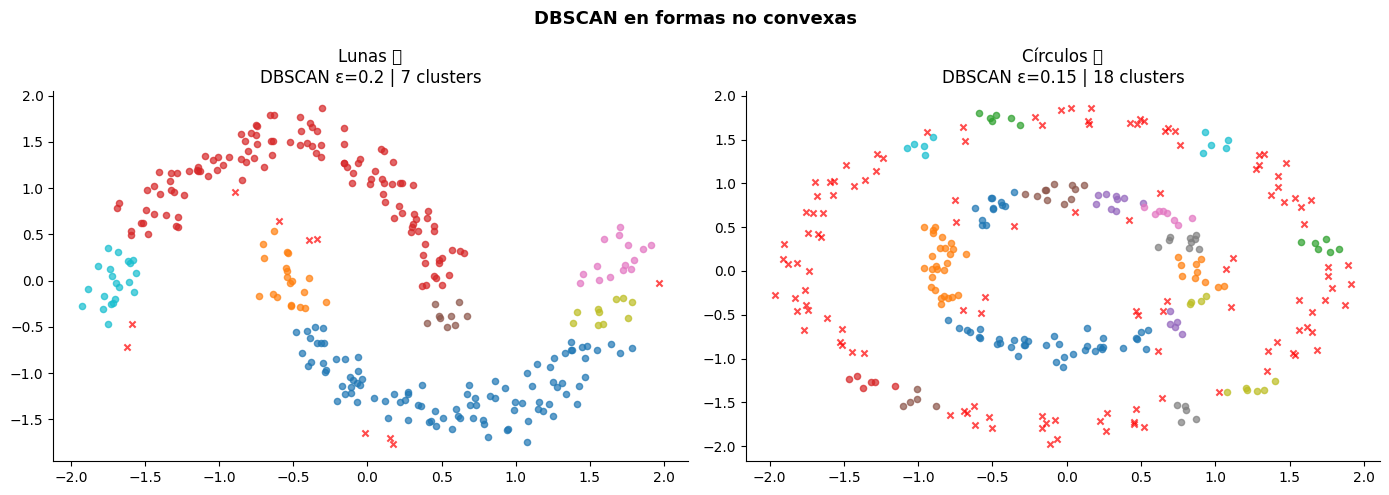

In [ ]:
# DBSCAN en lunas y círculos (donde K-Means fallaba)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    (X_moons, 'Lunas', 0.2, 5),
    (X_circles, 'Círculos', 0.15, 5),
]

for ax, (X, title, eps, mpts) in zip(axes, configs):
    X_sc = StandardScaler().fit_transform(X)
    db = DBSCAN(eps=eps, min_samples=mpts)
    labels = db.fit_predict(X_sc)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    palette = plt.cm.tab10(np.linspace(0, 1, max(n_cl, 1)))
    for lab in set(labels):
        mask = labels == lab
        c = 'red' if lab == -1 else [palette[lab]]
        m = 'x' if lab == -1 else 'o'
        ax.scatter(X_sc[mask, 0], X_sc[mask, 1], c=c, marker=m, alpha=0.7, s=20)
    ax.set_title(f'{title} ✅\nDBSCAN ε={eps} | {n_cl} clusters', fontsize=12)
plt.suptitle('DBSCAN en formas no convexas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 🔬 Ejercicio S3
> 1. Experimentá con distintos valores de `eps` (0.1, 0.2, 0.4, 0.6) en `X_noisy`.
>    ¿Qué pasa con el número de clusters y los puntos de ruido?
> 2. ¿Cuál sería el efecto de un `eps` muy pequeño? ¿Y muy grande?
> 3. **Bonus:** DBSCAN no maneja bien clusters de **densidades muy distintas**. Generá un dataset
>    con 2 blobs de densidades diferentes y demostrá este problema.


In [ ]:
# Tu código aquí
for eps_val in [0.1, 0.2, 0.4, 0.6]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(X_noisy_scaled)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f'eps={eps_val:.1f} → clusters: {n_cl} | ruido: {n_noise}')


eps=0.1 → clusters: 3 | ruido: 35
eps=0.2 → clusters: 3 | ruido: 26
eps=0.4 → clusters: 5 | ruido: 13
eps=0.6 → clusters: 1 | ruido: 4


---
## 🗺️ S4 · SOM: Mapas Auto-Organizados

Un **SOM** (Self-Organizing Map) proyecta datos de alta dimensión en una grilla 2D de neuronas
preservando las relaciones topológicas (puntos similares → neuronas vecinas).

### Proceso de aprendizaje:
1. Presentar un vector de entrada **x**
2. Encontrar la **BMU** (Best Matching Unit) — neurona con pesos más similares a **x**
3. Actualizar la BMU **y sus vecinas** hacia **x** con tasa de aprendizaje η y radio σ
4. Decrementar η y σ gradualmente

### Librería: `minisom`

In [ ]:
# Verificar e instalar minisom si es necesario
try:
    from minisom import MiniSom
    print('✅ MiniSom disponible')
except ImportError:
    print('Instalando minisom...')
    import subprocess
    subprocess.run(['pip', 'install', 'minisom', '-q'])
    from minisom import MiniSom
    print('✅ MiniSom instalado')

Instalando minisom...
✅ MiniSom instalado


In [ ]:
from minisom import MiniSom

# Normalizar datos
X_blobs_scaled = StandardScaler().fit_transform(X_blobs)

# Configurar SOM: grilla 8x8, 2 dimensiones de entrada
som_x, som_y = 8, 8
som = MiniSom(x=som_x, y=som_y, input_len=2,
              sigma=1.5, learning_rate=0.5,
              neighborhood_function='gaussian',
              random_seed=42)

# Inicializar pesos
som.random_weights_init(X_blobs_scaled)

# Entrenar
n_iters = 1000
som.train_random(X_blobs_scaled, n_iters, verbose=False)

print(f'✅ SOM entrenado: grilla {som_x}×{som_y} | {n_iters} iteraciones')

# Mapear cada punto a su BMU
bmu_positions = np.array([som.winner(x) for x in X_blobs_scaled])
print(f'Posiciones BMU únicas: {len(set(map(tuple, bmu_positions)))}')

✅ SOM entrenado: grilla 8×8 | 1000 iteraciones
Posiciones BMU únicas: 50


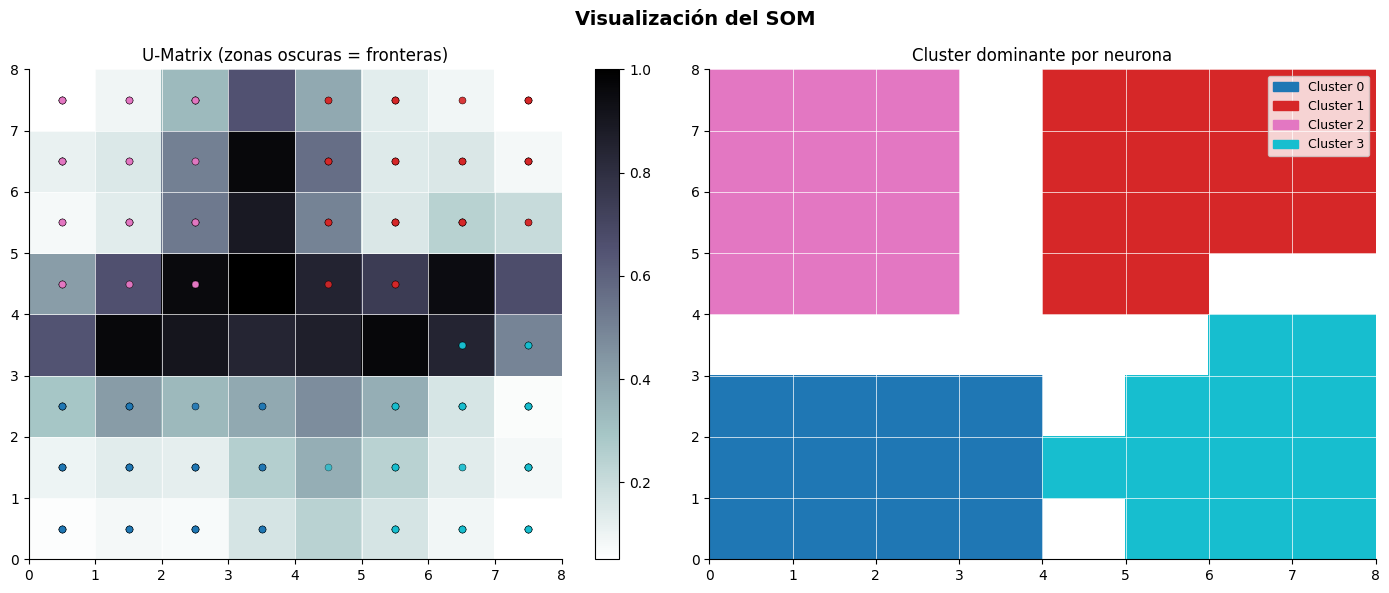

In [ ]:
# Visualización: U-Matrix + proyección de puntos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# U-Matrix (distancias entre neuronas vecinas)
u_matrix = som.distance_map()
im = axes[0].pcolor(u_matrix.T, cmap='bone_r')
plt.colorbar(im, ax=axes[0])
# Superponer puntos coloreados por cluster real
cmap = plt.cm.tab10
for idx, x in enumerate(X_blobs_scaled):
    bmu = som.winner(x)
    axes[0].plot(bmu[0] + 0.5, bmu[1] + 0.5, 'o',
               markerfacecolor=cmap(y_blobs[idx] / 3.0),
               markeredgecolor='k', markeredgewidth=0.3,
               markersize=5, alpha=0.7)
axes[0].set_title('U-Matrix (zonas oscuras = fronteras)', fontsize=12)
axes[0].set_xticks(np.arange(0, som_x+1, 1), minor=False)
axes[0].set_yticks(np.arange(0, som_y+1, 1), minor=False)
axes[0].grid(True, which='major', color='white', linewidth=0.5)

# Heatmap de activaciones por cluster
activation_maps = np.zeros((4, som_x, som_y))
for idx, x in enumerate(X_blobs_scaled):
    bx, by = som.winner(x)
    activation_maps[y_blobs[idx], bx, by] += 1

# Cluster con más activaciones por neurona
dominant = np.argmax(activation_maps, axis=0)
activity = activation_maps.sum(axis=0)
masked = np.ma.masked_where(activity == 0, dominant)
axes[1].pcolor(masked.T, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Cluster dominante por neurona', fontsize=12)
patches = [mpatches.Patch(color=cmap(i/3.0), label=f'Cluster {i}') for i in range(4)]
axes[1].legend(handles=patches, loc='upper right', fontsize=9)
axes[1].set_xticks(np.arange(0, som_x+1, 1))
axes[1].set_yticks(np.arange(0, som_y+1, 1))
axes[1].grid(True, which='major', color='white', linewidth=0.5)

plt.suptitle('Visualización del SOM', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 🔬 Ejercicio S4
> 1. Entrenamos el SOM con grilla 8×8. Probá con 6×6 y 12×12. ¿Cómo cambia la U-Matrix?
> 2. ¿Cuántas iteraciones de entrenamiento son suficientes? Probá con 200, 500, 2000.
> 3. **Bonus:** Aplicá SOM al dataset `X_moons`. ¿Puede el SOM capturar la forma de las lunas?


In [ ]:
# Tu código aquí
# Tip: cambiá som_x, som_y y n_iters en la configuración del SOM


---
## 📊 S5 · Métricas de Evaluación

Sin etiquetas verdaderas, usamos métricas **internas** para evaluar la calidad del clustering.

| Métrica | Rango | Mejor valor | Qué mide |
|---------|-------|-------------|----------|
| **Silhouette** | [-1, 1] | → 1 | Separación y cohesión |
| **Davies-Bouldin** | [0, ∞) | → 0 | Similitud entre clusters |
| **Calinski-Harabász** | [0, ∞) | → ∞ | Dispersión inter/intra |

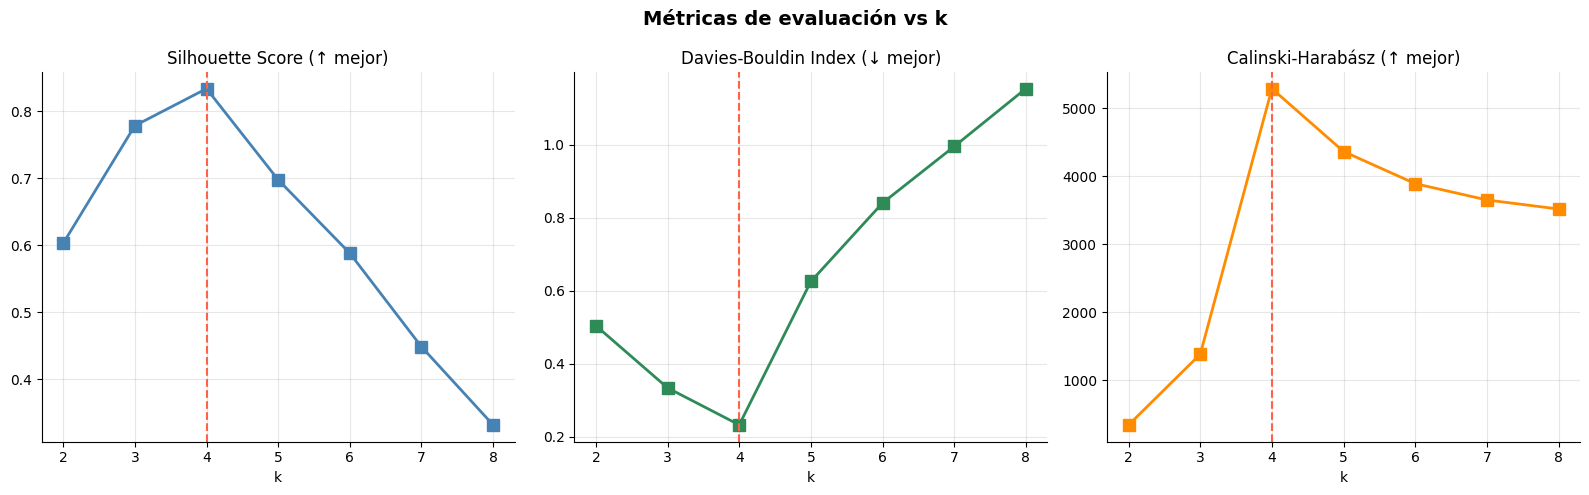


Tabla de métricas:
   silhouette  davies_bouldin  calinski_harabasz
k                                               
2      0.6030          0.5039           341.9283
3      0.7783          0.3336          1381.8850
4      0.8335          0.2322          5285.6086
5      0.6976          0.6251          4361.4298
6      0.5882          0.8400          3889.1173
7      0.4487          0.9949          3649.0989
8      0.3322          1.1533          3515.9777


In [ ]:
# Comparativa de métricas para distintos k en X_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_vals = range(2, 9)
results = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in k_vals:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_blobs)
    results['k'].append(k)
    results['silhouette'].append(silhouette_score(X_blobs, labels))
    results['davies_bouldin'].append(davies_bouldin_score(X_blobs, labels))
    results['calinski_harabasz'].append(calinski_harabasz_score(X_blobs, labels))

df_metrics = pd.DataFrame(results).set_index('k')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(df_metrics.index, df_metrics['silhouette'], 's-', color='steelblue', lw=2, ms=8)
axes[0].set_title('Silhouette Score (↑ mejor)', fontsize=12)
axes[0].axvline(x=df_metrics['silhouette'].idxmax(), color='tomato', linestyle='--')
axes[0].set_xlabel('k'); axes[0].grid(alpha=0.3)

axes[1].plot(df_metrics.index, df_metrics['davies_bouldin'], 's-', color='seagreen', lw=2, ms=8)
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontsize=12)
axes[1].axvline(x=df_metrics['davies_bouldin'].idxmin(), color='tomato', linestyle='--')
axes[1].set_xlabel('k'); axes[1].grid(alpha=0.3)

axes[2].plot(df_metrics.index, df_metrics['calinski_harabasz'], 's-', color='darkorange', lw=2, ms=8)
axes[2].set_title('Calinski-Harabász (↑ mejor)', fontsize=12)
axes[2].axvline(x=df_metrics['calinski_harabasz'].idxmax(), color='tomato', linestyle='--')
axes[2].set_xlabel('k'); axes[2].grid(alpha=0.3)

plt.suptitle('Métricas de evaluación vs k', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTabla de métricas:')
print(df_metrics.round(4).to_string())

### 🔬 Ejercicio S5
> 1. Calculá las tres métricas para K-Means con k=2,3,4,5 en el dataset `X_moons`.
> 2. ¿Los valores de las métricas reflejan la mala calidad del clustering? ¿Por qué sí o no?
> 3. **Reflexión:** ¿Podemos confiar ciegamente en estas métricas? ¿Cuándo podrían engañarnos?


In [ ]:
# Tu código aquí


---
## 💼 S6 · Caso Real: Segmentación RFM de Clientes

**RFM** es un framework clásico de segmentación de clientes basado en:
- **R**ecency: ¿Cuándo fue la última compra?
- **F**requency: ¿Con qué frecuencia compra?
- **M**onetary: ¿Cuánto gasta?

Vamos a generar un dataset sintético de clientes y aplicar el pipeline completo.

In [ ]:
# Generar dataset RFM sintético
np.random.seed(42)
n_customers = 500

# Definir 4 segmentos reales
segments_config = [
    # (n, recency_mean, recency_std, freq_mean, freq_std, monetary_mean, monetary_std)
    (150, 5,   3,  20,  5, 5000, 1000),   # Champions: compra reciente, frecuente, alto gasto
    (120, 60,  20, 10,  3, 2000, 500),    # Leales: moderado recency, frecuencia media
    (130, 150, 40,  3,  2,  800, 300),    # En riesgo: recency alto, poco frecuente
    (100, 300, 50,  1,  1,  200, 100),    # Perdidos: no compran hace mucho
]

records = []
for i, (n, rm, rs, fm, fs, mm, ms) in enumerate(segments_config):
    r = np.abs(np.random.normal(rm, rs, n)).astype(int)
    f = np.abs(np.random.normal(fm, fs, n)).astype(int) + 1
    m = np.abs(np.random.normal(mm, ms, n)).astype(int)
    seg = ['Champions', 'Leales', 'En Riesgo', 'Perdidos'][i]
    for j in range(n):
        records.append({'recency': r[j], 'frequency': f[j], 'monetary': m[j], 'true_segment': seg})

df_rfm = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print(df_rfm.head(10))
print(f'\nShape: {df_rfm.shape}')
print('\nEstadísticas descriptivas:')
print(df_rfm[['recency','frequency','monetary']].describe().round(1))

   recency  frequency  monetary true_segment
0      134          1      1487    En Riesgo
1        9         12      5959    Champions
2      146          3       573    En Riesgo
3       44          4      1845       Leales
4        4         13      4549    Champions
5      167          3       322    En Riesgo
6      157          1       770    En Riesgo
7        6         16      5645    Champions
8        6         18      5097    Champions
9      316          1       230     Perdidos

Shape: (500, 4)

Estadísticas descriptivas:
       recency  frequency  monetary
count    500.0      500.0     500.0
mean     116.3       10.1    2257.3
std      113.7        8.4    2018.0
min        0.0        1.0       3.0
25%        7.0        3.0     508.0
50%       75.0        8.0    1528.0
75%      192.5       16.0    4162.8
max      428.0       40.0    7189.0


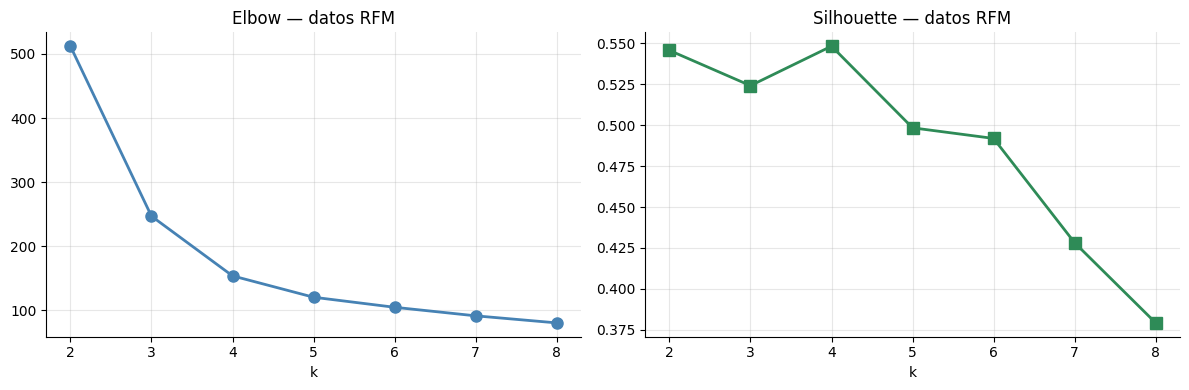

Mejor k por Silhouette: 4


In [ ]:
# Pipeline completo: escalar → K-Means → evaluar → visualizar

# 1. Preparar features
X_rfm = df_rfm[['recency', 'frequency', 'monetary']].values

# 2. Escalar (crítico: recency está en días, monetary en $)
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

# 3. Elbow + Silhouette para elegir k
inertias_rfm = []
sil_rfm = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_rfm_scaled)
    inertias_rfm.append(km.inertia_)
    sil_rfm.append(silhouette_score(X_rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 9), inertias_rfm, 'o-', color='steelblue', lw=2, ms=8)
axes[0].set_title('Elbow — datos RFM'); axes[0].set_xlabel('k'); axes[0].grid(alpha=0.3)
axes[1].plot(range(2, 9), sil_rfm, 's-', color='seagreen', lw=2, ms=8)
axes[1].set_title('Silhouette — datos RFM'); axes[1].set_xlabel('k'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Mejor k por Silhouette: {range(2,9)[np.argmax(sil_rfm)]}')

In [ ]:
# 4. Entrenar K-Means con k=4
km_rfm = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=42)
df_rfm['cluster'] = km_rfm.fit_predict(X_rfm_scaled)

# 5. Caracterizar segmentos
profile = df_rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(1)
profile['count'] = df_rfm.groupby('cluster').size()
print('Perfil por cluster:')
print(profile.sort_values('monetary', ascending=False))

# 6. Asignar nombres de negocio
# (ordenamos por monetary descendente)
cluster_order = profile['monetary'].sort_values(ascending=False).index.tolist()
nombres = ['Champions 🏆', 'Leales 💙', 'En Riesgo ⚠️', 'Perdidos 😴']
name_map = {c: n for c, n in zip(cluster_order, nombres)}
df_rfm['segmento'] = df_rfm['cluster'].map(name_map)
print('\nDistribución de segmentos:')
print(df_rfm['segmento'].value_counts())

Perfil por cluster:
         recency  frequency  monetary  count
cluster                                     
0            4.4       21.0    5090.9    147
2           54.9       10.7    2029.7    122
1          156.3        3.8     830.3    131
3          303.2        1.7     238.8    100

Distribución de segmentos:
segmento
Champions 🏆     147
En Riesgo ⚠️    131
Leales 💙        122
Perdidos 😴      100
Name: count, dtype: int64


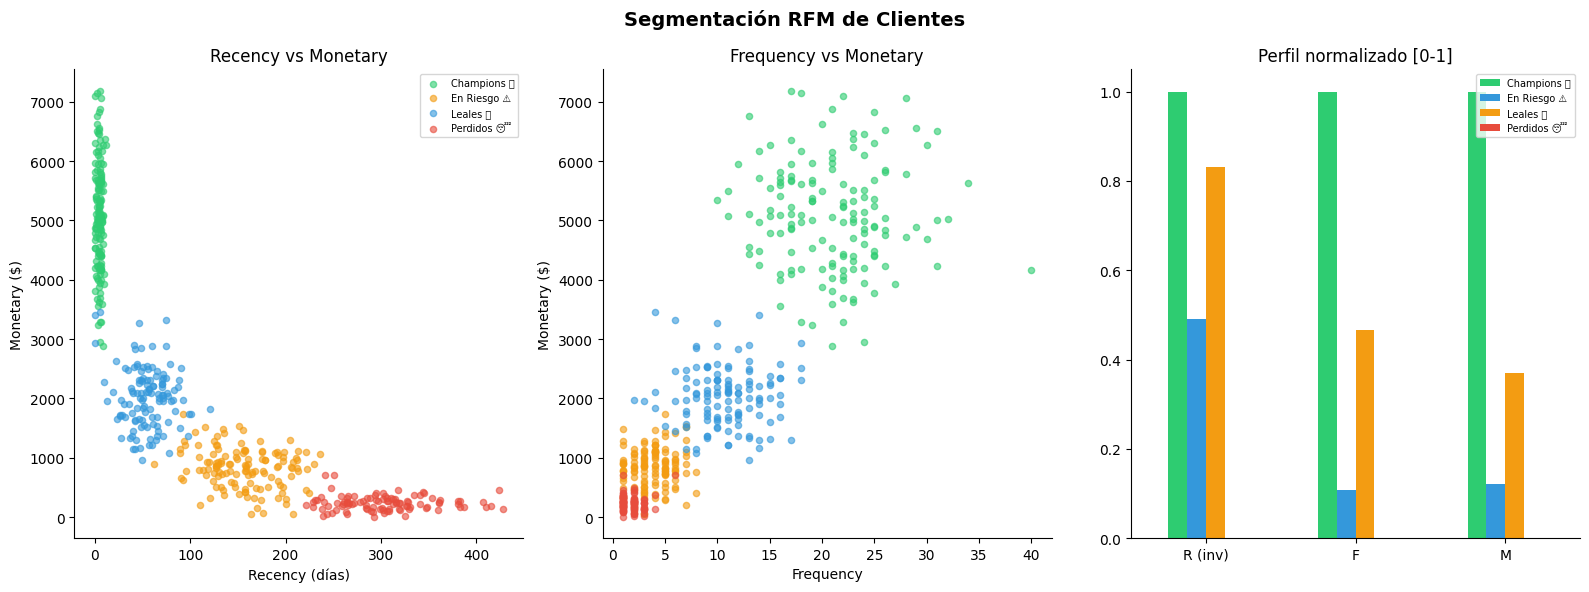


Métricas de evaluación:
  Silhouette:         0.5484  (mayor es mejor)
  Davies-Bouldin:     0.5832  (menor es mejor)
  Calinski-Harabász:  1448.4  (mayor es mejor)


In [ ]:
# 7. Visualización final
fig = plt.figure(figsize=(16, 6))

# Scatter: Recency vs Monetary
ax1 = fig.add_subplot(131)
colors_seg = {'Champions 🏆': '#2ECC71', 'Leales 💙': '#3498DB',
              'En Riesgo ⚠️': '#F39C12', 'Perdidos 😴': '#E74C3C'}
for seg, grp in df_rfm.groupby('segmento'):
    ax1.scatter(grp['recency'], grp['monetary'],
               label=seg, alpha=0.6, s=20, color=colors_seg[seg])
ax1.set_xlabel('Recency (días)'); ax1.set_ylabel('Monetary ($)')
ax1.set_title('Recency vs Monetary')
ax1.legend(fontsize=7)

# Scatter: Frequency vs Monetary
ax2 = fig.add_subplot(132)
for seg, grp in df_rfm.groupby('segmento'):
    ax2.scatter(grp['frequency'], grp['monetary'],
               label=seg, alpha=0.6, s=20, color=colors_seg[seg])
ax2.set_xlabel('Frequency'); ax2.set_ylabel('Monetary ($)')
ax2.set_title('Frequency vs Monetary')

# Radar / Bar: perfil de segmentos
ax3 = fig.add_subplot(133)
profile_norm = profile[['recency','frequency','monetary']].copy()
for col in profile_norm.columns:
    if col == 'recency':  # recency: menor es mejor → invertir
        profile_norm[col] = 1 - (profile_norm[col] - profile_norm[col].min()) / \
                                (profile_norm[col].max() - profile_norm[col].min() + 1e-9)
    else:
        profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / \
                             (profile_norm[col].max() - profile_norm[col].min() + 1e-9)
profile_norm.index = [name_map[c] for c in profile_norm.index]
profile_norm.T.plot(kind='bar', ax=ax3, color=list(colors_seg.values())[:4])
ax3.set_title('Perfil normalizado [0-1]')
ax3.set_xticklabels(['R (inv)', 'F', 'M'], rotation=0)
ax3.legend(fontsize=7)

plt.suptitle('Segmentación RFM de Clientes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nMétricas de evaluación:')
sil = silhouette_score(X_rfm_scaled, df_rfm['cluster'])
db = davies_bouldin_score(X_rfm_scaled, df_rfm['cluster'])
ch = calinski_harabasz_score(X_rfm_scaled, df_rfm['cluster'])
print(f'  Silhouette:         {sil:.4f}  (mayor es mejor)')
print(f'  Davies-Bouldin:     {db:.4f}  (menor es mejor)')
print(f'  Calinski-Harabász:  {ch:.1f}  (mayor es mejor)')

### 🔬 Ejercicio S6 (integrador)
> Tenés a tu disposición el dataset `df_rfm`. Tu misión:
>
> 1. Aplicá **DBSCAN** al dataset RFM escalado. ¿Detecta outliers? ¿Los outliers son clientes reales o ruido?
> 2. Compará los resultados de K-Means vs DBSCAN usando las métricas de evaluación.
> 3. Proyectá los clusters en 2D con **PCA** para visualizar la separación.
> 4. **Reflexión de negocio:** Para cada segmento que encontraste con K-Means, propone una acción de marketing concreta (ej: descuento, reactivación, programa VIP, etc.).


In [ ]:
# Tu código aquí
# Tip PCA: pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_rfm_scaled)
# Tip DBSCAN en RFM: probá eps=0.5, min_samples=10


---
## 🏁 S7 · Comparativa y Cierre

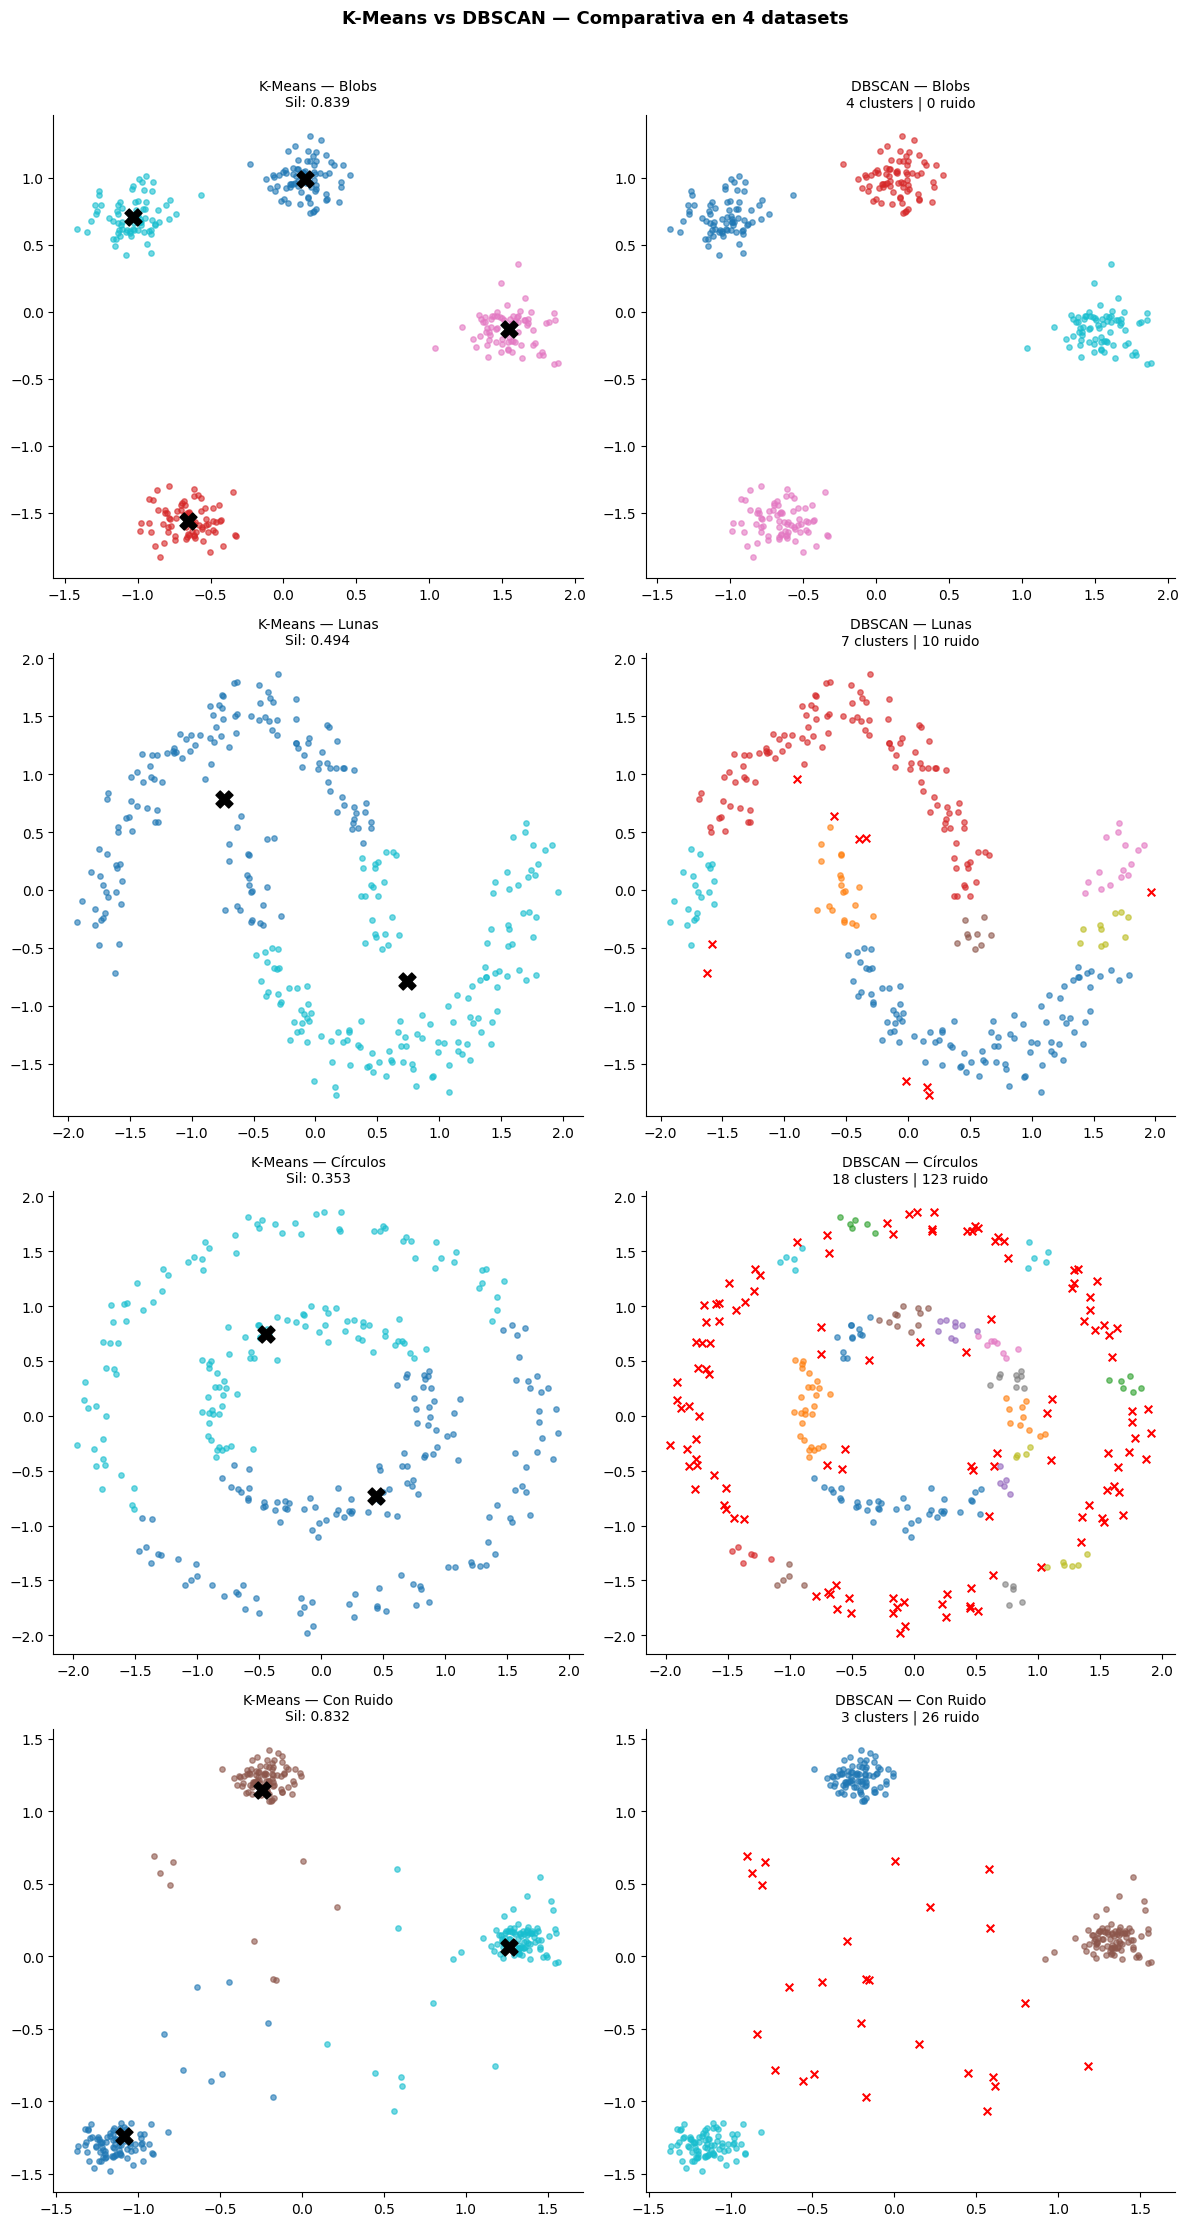

In [ ]:
# Comparativa visual: K-Means vs DBSCAN en los 4 datasets
fig, axes = plt.subplots(4, 2, figsize=(12, 22))

datasets_comp = [
    (X_blobs, 'Blobs', 4, 0.3, 5),
    (X_moons, 'Lunas', 2, 0.2, 5),
    (X_circles, 'Círculos', 2, 0.15, 5),
    (X_noisy, 'Con Ruido', 3, 0.3, 5),
]

for row, (X, title, k, eps, mpts) in enumerate(datasets_comp):
    X_sc = StandardScaler().fit_transform(X)

    # K-Means
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lkm = km.fit_predict(X_sc)
    sil_km = silhouette_score(X_sc, lkm)
    colors = plt.cm.tab10(np.linspace(0, 1, k))
    for ki in range(k):
        axes[row, 0].scatter(X_sc[lkm==ki, 0], X_sc[lkm==ki, 1],
                            c=[colors[ki]], alpha=0.6, s=15)
    axes[row, 0].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
                        marker='X', s=150, c='k', zorder=5)
    axes[row, 0].set_title(f'K-Means — {title}\nSil: {sil_km:.3f}', fontsize=10)

    # DBSCAN
    db = DBSCAN(eps=eps, min_samples=mpts)
    ldb = db.fit_predict(X_sc)
    n_cl = len(set(ldb)) - (1 if -1 in ldb else 0)
    n_noise = (ldb == -1).sum()
    pal = plt.cm.tab10(np.linspace(0, 1, max(n_cl, 1)))
    for lab in set(ldb):
        mask = ldb == lab
        if lab == -1:
            axes[row, 1].scatter(X_sc[mask, 0], X_sc[mask, 1],
                                c='red', marker='x', s=30, label='Ruido')
        else:
            axes[row, 1].scatter(X_sc[mask, 0], X_sc[mask, 1],
                                c=[pal[lab]], alpha=0.6, s=15)
    axes[row, 1].set_title(f'DBSCAN — {title}\n{n_cl} clusters | {n_noise} ruido', fontsize=10)

plt.suptitle('K-Means vs DBSCAN — Comparativa en 4 datasets', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 📋 Resumen de la Semana 6

### ¿Cuándo usar cada algoritmo?

| Situación | Algoritmo recomendado |
|-----------|---------------------|
| Clusters esféricos y bien separados | **K-Means** |
| Formas arbitrarias o ruido/outliers | **DBSCAN** |
| Datos de alta dimensión + visualización | **SOM** |
| No sé cuántos clusters hay | **DBSCAN** o HDBSCAN |
| Necesito interpretar clusters fácilmente | **K-Means** + elbow |
| Datos de texto/embeddings | **K-Means** con distancia coseno |

### Pipeline recomendado:
```
1. Explorar datos (distribución, outliers, escala)
2. Escalar con StandardScaler
3. Aplicar elbow + silhouette (K-Means) o k-distance graph (DBSCAN)
4. Entrenar el modelo elegido
5. Evaluar con Silhouette + Davies-Bouldin + Calinski-Harabász
6. Interpretar clusters en términos de negocio
7. Validar con expertos del dominio
```

### Conceptos clave:
- **Clustering** = aprendizaje no supervisado, sin etiquetas
- **K-Means** = minimiza inercia, requiere k, asume formas esféricas
- **DBSCAN** = basado en densidad, detecta ruido, no requiere k
- **SOM** = proyección topológica, útil para visualización
- Siempre **escalar** antes de aplicar algoritmos de distancia


---
## 📌 Checklist de entrega

Antes de entregar el notebook, verificá que:

- [ ] Todas las celdas ejecutan sin errores
- [ ] Completaste todos los ejercicios (S1 al S6)
- [ ] El ejercicio S6.4 incluye reflexión de negocio con acciones concretas
- [ ] Guardaste el notebook como `apellido_MDD_S6_Clustering.ipynb`

---
*Tecnicatura Superior en Ciencias de Datos e Inteligencia Artificial · Politécnico Malvinas Argentinas*
